In [ ]:
import numpy
import torch
import torch.nn as nn
from torchvision import datasets
import torch.optim as optim
from torchvision.transforms import ToTensor
from torch.utils.data import random_split
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

10000
Новая лучшая модель сохранена! Точность: 89.90%
Epoch 1/10:
  Train Loss: 0.9866, Train Accuracy: 89.40%
  Val Loss: 0.3539, Val Accuracy: 89.90%
--------------------------------------------------
Новая лучшая модель сохранена! Точность: 91.90%
Epoch 2/10:
  Train Loss: 0.3600, Train Accuracy: 92.66%
  Val Loss: 0.2670, Val Accuracy: 91.90%
--------------------------------------------------
Новая лучшая модель сохранена! Точность: 93.40%
Epoch 3/10:
  Train Loss: 0.2726, Train Accuracy: 93.80%
  Val Loss: 0.2211, Val Accuracy: 93.40%
--------------------------------------------------
Новая лучшая модель сохранена! Точность: 94.40%
Epoch 4/10:
  Train Loss: 0.2146, Train Accuracy: 95.67%
  Val Loss: 0.1794, Val Accuracy: 94.40%
--------------------------------------------------
Новая лучшая модель сохранена! Точность: 95.40%
Epoch 5/10:
  Train Loss: 0.1754, Train Accuracy: 96.61%
  Val Loss: 0.1532, Val Accuracy: 95.40%
--------------------------------------------------
Новая луч

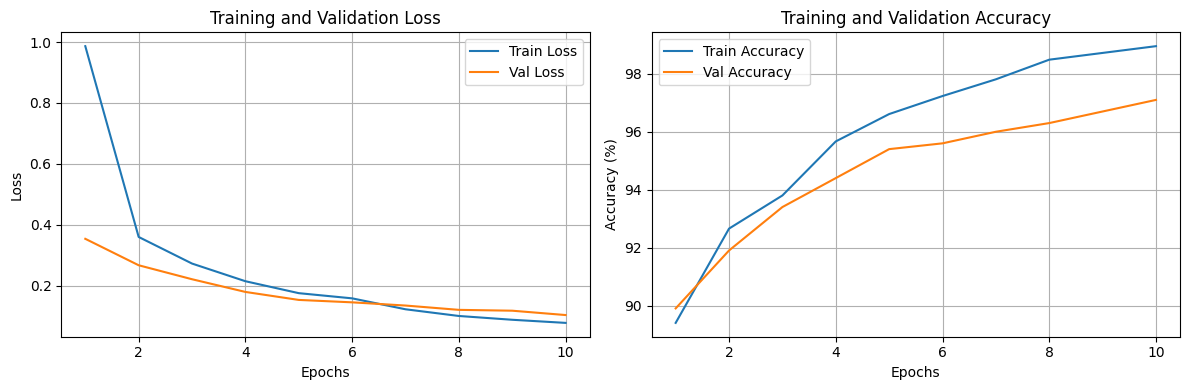

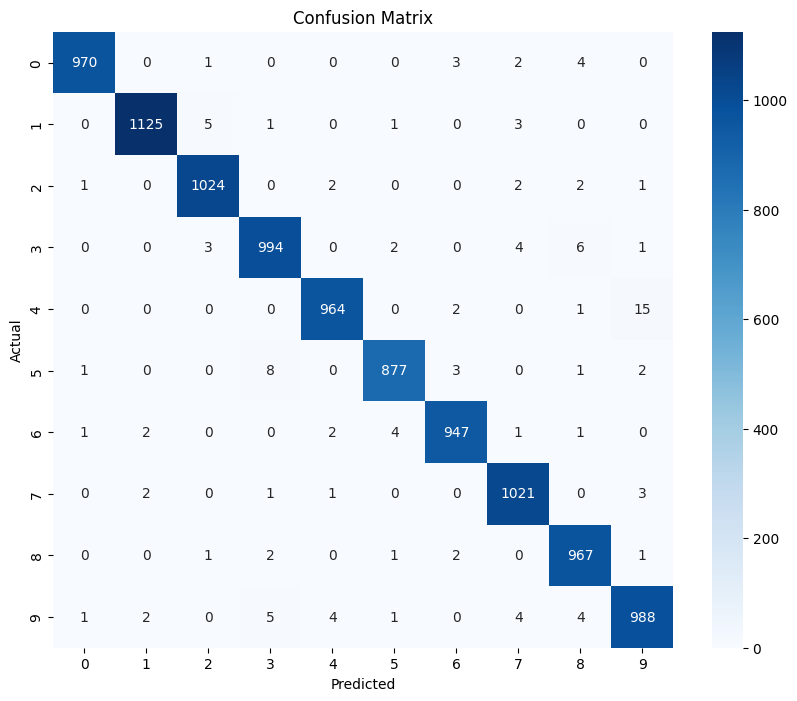

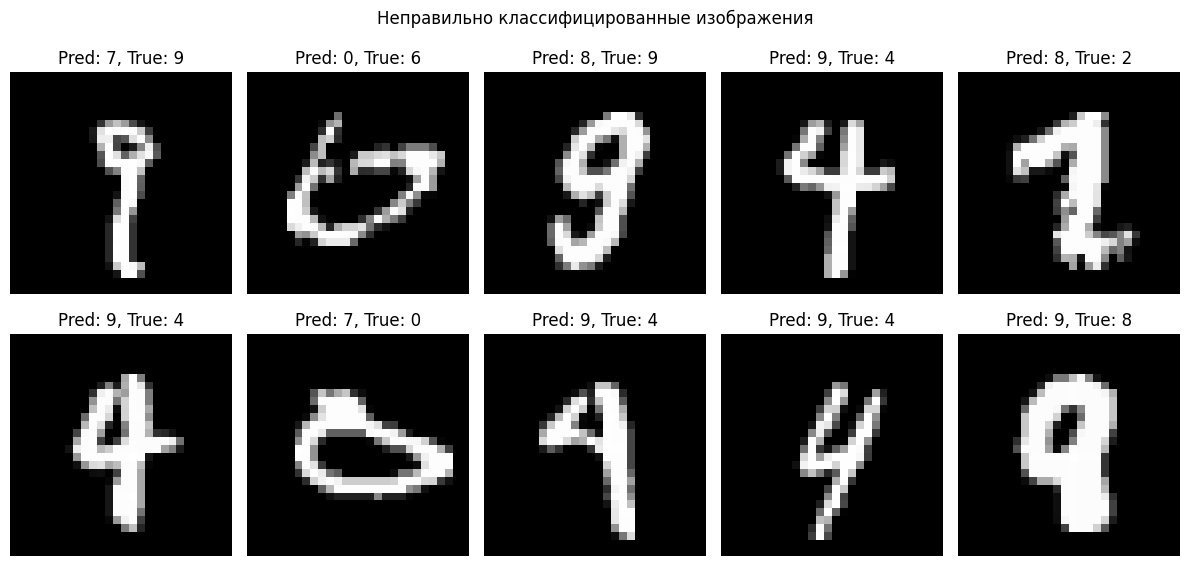

In [ ]:
test_data = datasets.MNIST(root='data', train=False,
                           download=True, transform=ToTensor())
test_data_size = len(test_data)
print(len(test_data))
epochs = 10         # количество эпох
batch_size = 128    # размер "пакета"
train_data, val_data = random_split(test_data, [int(test_data_size*0.9),
                                                int(test_data_size*0.1)])  # 90%/10%

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

'''
class: MLP
Класс необходим для преобразования изображения 28х28 в тензор
'''
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden1=256, hidden2=128, output_size=10, dropout_rate=0.2):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),  # Преобразует изображение 28x28 в вектор (тензор) 784
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden2, output_size)
        )

    def forward(self, x):
        return self.model(x)

# Инициализация модели
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_accuracy = 0.0

'''
Функция: Вычисление точности
Главные переменные: correct — верные значения
                    total   — все значения
'''
def calculate_accuracy(loader, model):
    correct = 0
    total = 0
    model.eval() # выключение обучения модели
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return 100 * correct / total

for epoch in range(epochs):
    # --- Фаза обучения ---
    model.train()
    running_loss = 0.0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        # Обнуляем градиенты
        optimizer.zero_grad()
        # Прямой проход
        outputs = model(data)
        # Вычисление ошибки
        loss = criterion(outputs, target)
        # Обратный проход + оптимизация
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Средняя ошибка за эпоху
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Фаза валидации ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            val_loss += criterion(outputs, target).item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Вычисление точности
    train_accuracy = calculate_accuracy(train_loader, model)
    val_accuracy = calculate_accuracy(val_loader, model)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Сохранение лучшей модели
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Новая лучшая модель сохранена! Точность: {val_accuracy:.2f}%")

    print(f'Epoch {epoch+1}/{epochs}:')
    print(f'  Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%')
    print(f'  Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')
    print('-' * 50)

plt.figure(figsize=(12, 4))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Графики Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, epochs+1), val_accuracies, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_results.png')
plt.show()

# --- Матрица ошибок и неправильные предсказания ---

# Загрузка лучшей модели для тестирования
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

# Создание матрицы ошибок
cm = confusion_matrix(all_targets, all_predictions)

# Визуализация матрицы ошибок
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

incorrect_examples = []
incorrect_predictions = []
incorrect_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)

        # Находим индексы неправильных предсказаний
        incorrect_mask = predicted != target
        incorrect_indices = incorrect_mask.nonzero(as_tuple=True)[0]

        for idx in incorrect_indices:
            if len(incorrect_examples) < 10:  # Покажем 10 примеров
                incorrect_examples.append(data[idx].cpu())
                incorrect_predictions.append(predicted[idx].cpu().item())
                incorrect_targets.append(target[idx].cpu().item())

# Отображение неправильно классифицированных изображений
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Неправильно классифицированные изображения')

for i, (img, pred, true) in enumerate(zip(incorrect_examples, incorrect_predictions, incorrect_targets)):
    ax = axes[i // 5, i % 5]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Pred: {pred}, True: {true}')
    ax.axis('off')

plt.tight_layout()
plt.savefig('incorrect_predictions.png')
plt.show()